# Notebook 2 — Preprocessing

| | |
|---|---|
| **Objetivo** | Realizar un correcto preprocesamiento del dataset. |
| **Dataset** | Palmer Penguins Dataset Extended |
| **Herramientas** | Pandas, matplotlib, seaborn, sklearn |

---

## Contenido
1. Manejo de variables categoricas
2. Escalado de features y transformacion

## 0. Importacion del dataset, copia del mismo y creacion del test_set

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df_original = pd.read_csv(r"E:\ROAD_TO_DATA_SCIENCE\PROYECTS\penguin-species-classification\data\raw\palmerpenguins_extended.csv")

In [4]:
df_penguins = df_original.copy()

In [5]:
from sklearn.model_selection import train_test_split

penguin_train_set, penguin_test_set = train_test_split(df_penguins, test_size=0.2, random_state=42)

In [6]:
penguin_train_set.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
1258,Adelie,Torgensen,30.9,13.7,199.0,4901.0,female,krill,adult,healthy,2023
932,Gentoo,Biscoe,24.8,17.5,205.0,5940.0,male,krill,juvenile,overweight,2022
572,Adelie,Torgensen,62.5,14.5,206.0,4664.0,female,fish,juvenile,overweight,2022
736,Chinstrap,Dream,32.0,17.4,211.0,4357.0,male,krill,juvenile,underweight,2022
2288,Gentoo,Biscoe,56.7,17.7,235.0,5689.0,female,fish,juvenile,overweight,2024


In [7]:
# Division de dataset en features y target
penguins = penguin_train_set.drop(["species", "life_stage"], axis=1)
penguins_labels = penguin_train_set["species"].copy()

print(penguins.shape)
print(penguins_labels.shape)

(2744, 9)
(2744,)


## Manejando los datos categoricos y de textos

Se creara un pipeline en donde como se habia revisado en el EDA al tener las features categoricas una baja cantidad de categorias se utilizara el OneHotEncoder

In [8]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown="ignore")
)

## Manejando los datos numericos

Como se concluyo en el EDA las features ``bill_length_mm``, ``flipper_length_mm``, ``body_mass_g`` cuentan con un sesgo hacia la izquierda es decir se ve una cola larga hacia la derecha ademas de que todas las features numericas tienen escalas muy distintas asi que requieren escalamiento, los pasos que se tomaran para solucionar esto seran 

1. Aplicar transformacion: logaritmica (heavy tail distribution) o Raiz cuadrada (power law distribution)
2. Revisar que escalamiento es mas optimo para este caso Min max scaling o standardization


In [9]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)

# 1. Aplicar transformacion logaritmica a las features
log_flipper = log_transformer.transform(penguins[["flipper_length_mm"]])
log_bill = log_transformer.transform(penguins[["bill_length_mm"]])
log_mass = log_transformer.transform(penguins[["body_mass_g"]])


Text(0.5, 1.0, 'body_mass_g - Despues')

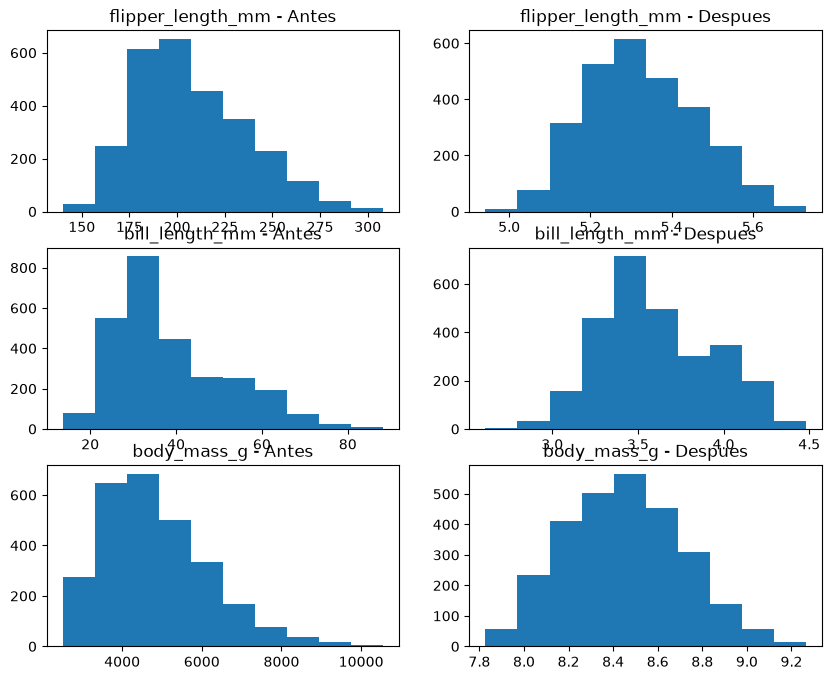

In [10]:
# Graficar para ver la diferencia
fig, axs = plt.subplots(3, 2, figsize=(10,8))

axs[0,0].hist(penguins["flipper_length_mm"])
axs[0,0].set_title("flipper_length_mm - Antes")

axs[0,1].hist(log_flipper)
axs[0,1].set_title("flipper_length_mm - Despues")

axs[1,0].hist(penguins["bill_length_mm"])
axs[1,0].set_title("bill_length_mm - Antes")

axs[1,1].hist(log_bill)
axs[1,1].set_title("bill_length_mm - Despues")

axs[2,0].hist(penguins["body_mass_g"])
axs[2,0].set_title("body_mass_g - Antes")

axs[2,1].hist(log_mass)
axs[2,1].set_title("body_mass_g - Despues")

Se observa una reducción del sesgo en las distribuciones, con una forma más simétrica después de aplicar la transformación logarítmica. Asi que esta se utilizaran en el pipeline de features numericas, ademas el porcentaje de outliers como revisamos en el EDA de estas features no es nula, asi que se utilizara como metodo de escalamiento la estandarizacion

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
log_pipeline = make_pipeline(
    FunctionTransformer(np.log, inverse_func=np.exp, feature_names_out="one-to-one"),
    StandardScaler()
)

In [13]:
num_pipeline = make_pipeline(
    StandardScaler()
)

## Pipeline de preprocesamiento

In [14]:
from sklearn.compose import ColumnTransformer

cat_attribs = ['island', 'sex', 'diet', 'health_metrics']

preprocessing = ColumnTransformer([
    ("log", log_pipeline, ["bill_length_mm", "flipper_length_mm", "body_mass_g", "year"]),
    ("cat", cat_pipeline, cat_attribs),
    ("num", num_pipeline, ["bill_depth_mm"])
])

In [15]:
#  Aplicar el pipeline de preprocesamiento al dataset
penguins_prepared = preprocessing.fit_transform(penguins)

In [16]:
penguins_prepared

array([[-0.52479404, -0.22984649,  0.1796024 , ...,  0.        ,
         0.        , -1.69608512],
       [-1.20121838, -0.01300058,  0.91110291, ...,  1.        ,
         0.        , -0.33436942],
       [ 1.64188703,  0.02252232, -0.00897328, ...,  1.        ,
         0.        , -1.40940813],
       ...,
       [-1.03230415, -1.68658367, -1.58024406, ...,  0.        ,
         0.        , -1.33773888],
       [ 2.0599867 ,  2.26297259,  2.2149445 , ...,  1.        ,
         0.        ,  3.3565968 ],
       [ 1.42263468,  1.80573656,  2.35202406, ...,  1.        ,
         0.        ,  1.88737723]], shape=(2744, 17))

In [17]:

# Obtener los nombres de las columnas
column_names = preprocessing.get_feature_names_out()

# Convertir el array a Dataframe asignando los nombres
penguins_prepared_df = pd.DataFrame(penguins_prepared, columns=column_names)

penguins_prepared_df.head()

,log__bill_length_mm,log__flipper_length_mm,log__body_mass_g,log__year,cat__island_Biscoe,cat__island_Dream,cat__island_Torgensen,cat__sex_female,cat__sex_male,cat__diet_fish,cat__diet_krill,cat__diet_parental,cat__diet_squid,cat__health_metrics_healthy,cat__health_metrics_overweight,cat__health_metrics_underweight,num__bill_depth_mm
0,-0.524794,-0.229846,0.179602,-0.283780,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-1.696085
1,-1.201218,-0.013001,0.911103,-1.052094,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.334369
2,1.641887,0.022522,-0.008973,-1.052094,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.409408
3,-0.417201,0.197589,-0.268024,-1.052094,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.370204
4,1.342320,0.983993,0.746843,0.484155,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.262700


## Aplicar el pipeline al test

In [18]:
penguin_test = penguin_test_set.drop(["species", "life_stage"], axis=1)

In [19]:
penguins_test_prepared = preprocessing.transform(penguin_test)

In [22]:
# Obtener los nombres de las columnas
column_names_test = preprocessing.get_feature_names_out()

# Convertir el array a Dataframe asignando los nombres
penguins_test_prepared_df = pd.DataFrame(penguins_test_prepared, columns=column_names_test)

penguins_test_prepared_df.head()

,log__bill_length_mm,log__flipper_length_mm,log__body_mass_g,log__year,cat__island_Biscoe,cat__island_Dream,cat__island_Torgensen,cat__sex_female,cat__sex_male,cat__diet_fish,cat__diet_krill,cat__diet_parental,cat__diet_squid,cat__health_metrics_healthy,cat__health_metrics_overweight,cat__health_metrics_underweight,num__bill_depth_mm
0,-1.152003,-0.340734,-0.625750,-1.052094,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-1.875258
1,0.175473,-0.921938,-0.490060,0.484155,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.083527
2,-0.388499,-0.084569,0.146075,-1.052094,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,-0.011858
3,-0.677854,-1.422702,-1.602500,1.251710,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,-1.588581
4,1.661510,0.402274,0.728071,0.484155,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.704835


## Verificar Resultados

### Tama;o

In [24]:
print(f"Numero de filas y columnas del train preprocesado: {penguins_prepared_df.shape}")
print(f"Numero de filas y columnas del test preprocesado: {penguins_test_prepared_df.shape}")

Numero de filas y columnas del train preprocesado: (2744, 17)
Numero de filas y columnas del test preprocesado: (686, 17)


Esta correcto, nos encontramos con el mismo numero de columnas y todas son las mismas, esto es exactamente lo que buscabamos para que luego no se produzcan errores al tratar de entrenar modelos.

### Valores faltantes

In [26]:
# Verificacion en dataset train
penguins_prepared_df.isna().sum()

log__bill_length_mm                0
log__flipper_length_mm             0
log__body_mass_g                   0
log__year                          0
cat__island_Biscoe                 0
cat__island_Dream                  0
cat__island_Torgensen              0
cat__sex_female                    0
cat__sex_male                      0
cat__diet_fish                     0
cat__diet_krill                    0
cat__diet_parental                 0
cat__diet_squid                    0
cat__health_metrics_healthy        0
cat__health_metrics_overweight     0
cat__health_metrics_underweight    0
num__bill_depth_mm                 0
dtype: int64

In [27]:
# Verificar en dataset test
penguins_test_prepared_df.isna().sum()

log__bill_length_mm                0
log__flipper_length_mm             0
log__body_mass_g                   0
log__year                          0
cat__island_Biscoe                 0
cat__island_Dream                  0
cat__island_Torgensen              0
cat__sex_female                    0
cat__sex_male                      0
cat__diet_fish                     0
cat__diet_krill                    0
cat__diet_parental                 0
cat__diet_squid                    0
cat__health_metrics_healthy        0
cat__health_metrics_overweight     0
cat__health_metrics_underweight    0
num__bill_depth_mm                 0
dtype: int64

Todo correcto en ambos datasets, no se presentan valores nulos despues del preprocesamiento.

### Verificar el escalado

In [28]:
penguins_prepared_df.describe()

,log__bill_length_mm,log__flipper_length_mm,log__body_mass_g,log__year,cat__island_Biscoe,cat__island_Dream,cat__island_Torgensen,cat__sex_female,cat__sex_male,cat__diet_fish,cat__diet_krill,cat__diet_parental,cat__diet_squid,cat__health_metrics_healthy,cat__health_metrics_overweight,cat__health_metrics_underweight,num__bill_depth_mm
count,2.744000e+03,2.744000e+03,2.744000e+03,2.744000e+03,2744.000000,2744.000000,2744.000000,2744.000000,2744.000000,2744.000000,2744.000000,2744.000000,2744.000000,2744.000000,2744.000000,2744.000000,2.744000e+03
mean,-1.074618e-15,4.722494e-15,5.577657e-15,-9.604886e-14,0.510569,0.331997,0.157434,0.496356,0.503644,0.282070,0.409257,0.251822,0.056851,0.450802,0.341837,0.207362,6.667812e-17
std,1.000182e+00,1.000182e+00,1.000182e+00,1.000182e+00,0.499979,0.471016,0.364276,0.500078,0.500078,0.450089,0.491786,0.434139,0.231600,0.497664,0.474412,0.405491,1.000182e+00
min,-3.049126e+00,-2.796962e+00,-2.369270e+00,-1.820788e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.344478e+00
25%,-7.199904e-01,-7.623700e-01,-7.441264e-01,-1.052094e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.568810e-01
50%,-1.680428e-01,-8.456922e-02,-1.877462e-02,4.841545e-01,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.185781e-02
75%,7.586518e-01,6.989264e-01,6.897393e-01,4.841545e-01,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,6.690000e-01
max,2.701344e+00,2.958731e+00,3.096140e+00,1.251710e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.392431e+00


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_title'

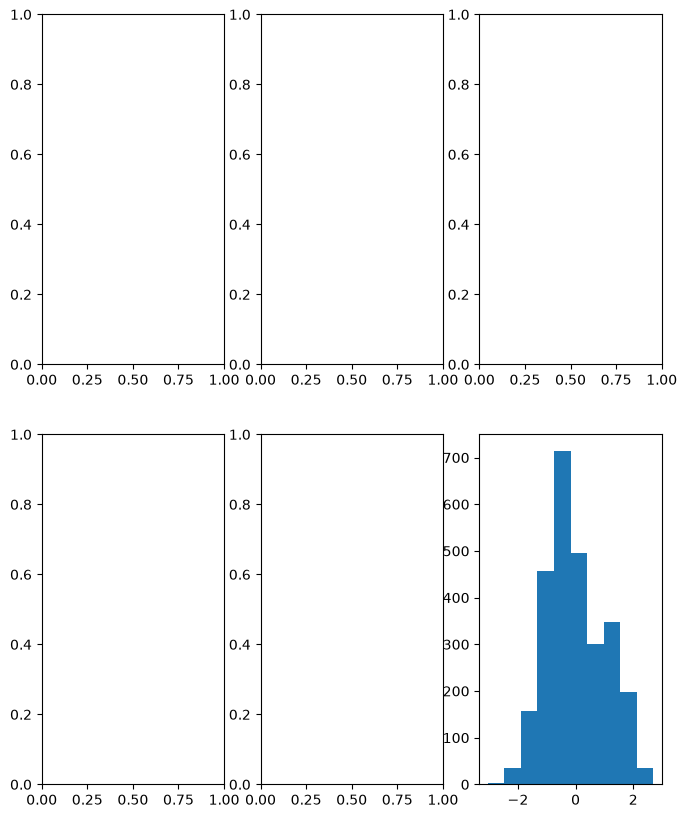

In [ ]:
fig, axes = plt.subplots(2,3, figsize=(8, 14))

axes[0,0] = plt.hist(penguins_prepared_df["log__bill_length_mm"])
axes[0,0] = plt.set_title("log__bill_length_mm")

plt.show()